# ДЗ №1 СУНЦ МГУ - Numpy practice

_Задачи позаимствованы из курса ML ФКН ПМИ где они были позаимствованы из курса практикума кафедры ММП факультета ВМК МГУ_ 

### Туториальные задачи
__(9 баллов)__

Ниже приведены задачи на работу с numpy-массивами. Для каждой из задач нужно привести 2 реализации: одна без использования numpy (cчитайте, что там, где на входе или выходе должны быть numpy array, будут просто списки), а вторая полностью векторизованная (без использования питоновских циклов/map/list comprehension). Невекторизованная реализация каждой из задач оценивается в __0.5 балла__, векторизованная – в __1 балл__.

Реализации без использования векторизации нужно записать в файл functions.py, а векторизованные &mdash; в файл functions_vectorized.py

Для каждой задачи, приведённой ниже сравните скорость работы невекторизованной и векторизованной реализации. С помощью пакета matplotlib постройте графики времени работы в зависимости от размера данных. __Графики должны выглядеть опрятно!__ То есть должны быть подписаны оси, названия графиков, и т.д. Например, ниже представлены хороший и плохой графики:

C:\Users\Святослав\AppData\Local\Temp\ipykernel_27840\3107362156.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


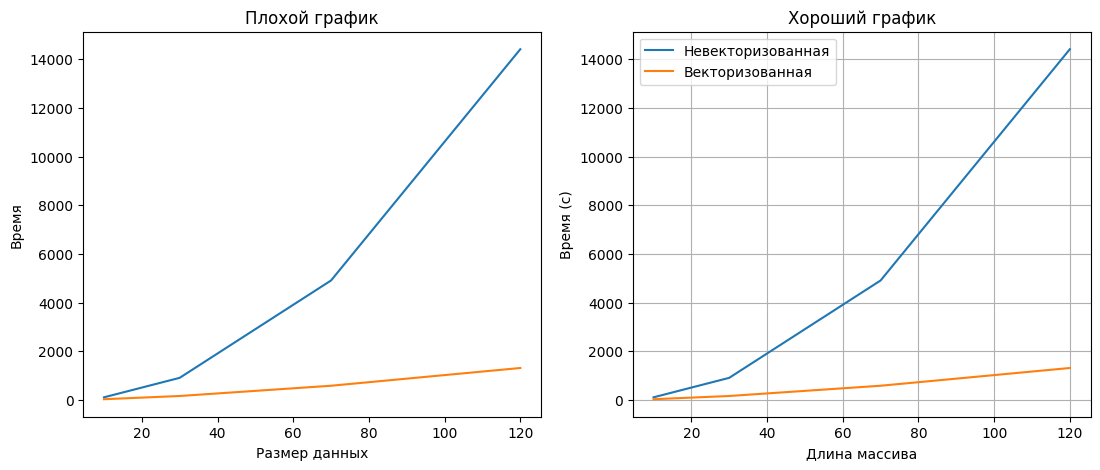

In [5]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

data_size = np.array([10, 30, 70, 120])
time_non_vectorized = data_size ** 2 + 10
time_vectorized = data_size ** 1.5

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(data_size, time_non_vectorized)
ax1.plot(data_size, time_vectorized)
ax1.set_title(u"Плохой график")
ax1.set_xlabel(u"Размер данных")
ax1.set_ylabel(u"Время")

ax2.plot(data_size, time_non_vectorized, label=u"Невекторизованная")
ax2.plot(data_size, time_vectorized, label=u"Векторизованная")
ax2.set_title(u"Хороший график")
ax2.set_xlabel(u"Длина массива")
ax2.set_ylabel(u"Время (с)")
ax2.grid()
ax2.legend()

f.show()              

* __Задача 1__: Подсчитать произведение ненулевых элементов на диагонали прямоугольной матрицы.  
 Например, для X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]]) ответ – 3.

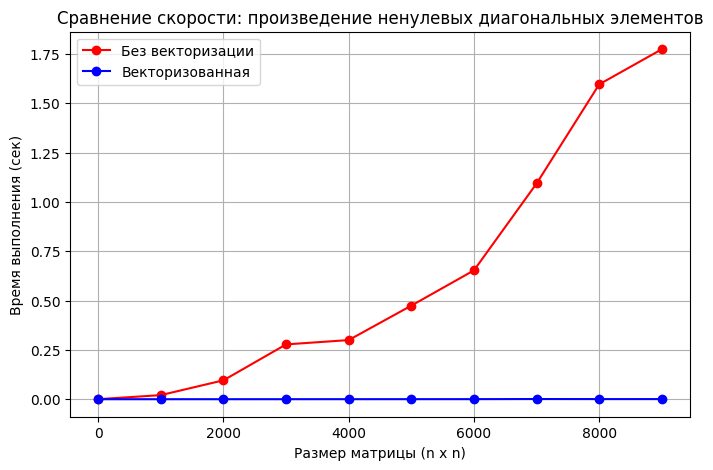

In [140]:
import numpy as np
import time
import matplotlib.pyplot as plt
from typing import List, Union

def use_np(matrix: np.ndarray):
    diagonal = np.diag(matrix)
    no_zero_diag = diagonal[diagonal != 0]
    return np.prod(no_zero_diag)

def not_use_np(matrix):
    p = 1
    n = min(len(matrix), len(matrix[0]))
    for i in range(n):
        if matrix[i][i] != 0:
            p *= matrix[i][i]
    return p

def generate_matrix(rows, cols):
    np_matrix = np.random.rand(rows, cols)
    list_matrix = np_matrix.tolist()
    return np_matrix, list_matrix

# Тестирование на матрицах разных размеров
sizes = []
for n in range(1,  10000, 1000):
    sizes.append(n)
times_use_np = []
times_not_use_np = []

for n in sizes:
    X = np.random.randint(0, 10, size=(n, n))

    start = time.time()
    not_use_np(X.tolist())
    times_not_use_np.append(time.time() - start)

    start = time.time()
    use_np(X)
    times_use_np.append(time.time() - start)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times_not_use_np, "r-o", label="Без векторизации")
plt.plot(sizes, times_use_np, "b-o", label="Векторизованная")
plt.xlabel("Размер матрицы (n x n)")
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение скорости: произведение ненулевых диагональных элементов")
plt.legend()
plt.grid(True)
plt.show()

 
 
* __Задача 2__: Даны два вектора x и y. Проверить, задают ли они одно и то же мультимножество.  
  Например, для x = np.array([1, 2, 2, 4]), y = np.array([4, 2, 1, 2]) ответ – True.
  
  


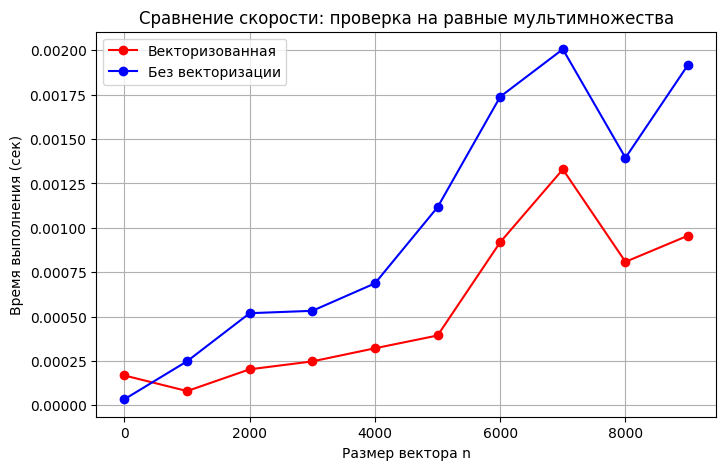

In [141]:
from collections import Counter

def use_np(x, y):
    mx = Counter(x)
    my = Counter(y)
    return (bool(1 - int(bool((mx - my) | (my - mx)))))

def not_use_np(x, y):
    mx = Counter(x)
    my = Counter(y)
    return mx == my

sizes = []
for n in range(1,  10000, 1000):
    sizes.append(n)
times_use_np = []
times_not_use_np = []

for n in sizes:
    X = np.random.randint(0, 10, size=n)
    Y = np.random.randint(0, 10, size=n)
    start = time.time()
    not_use_np(X.tolist(), Y.tolist())
    times_not_use_np.append(time.time() - start)

    start = time.time()
    use_np(X, Y)
    times_use_np.append(time.time() - start)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times_not_use_np, "r-o", label="Векторизованная")
plt.plot(sizes, times_use_np, "b-o", label="Без векторизации")
plt.xlabel("Размер вектора n")
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение скорости: проверка на равные мультимножества")
plt.legend()
plt.grid(True)
plt.show()

* __Задача 3__: Найти максимальный элемент в векторе x среди элементов, перед которыми стоит нулевой.  
 Например, для x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0]) ответ – 5.

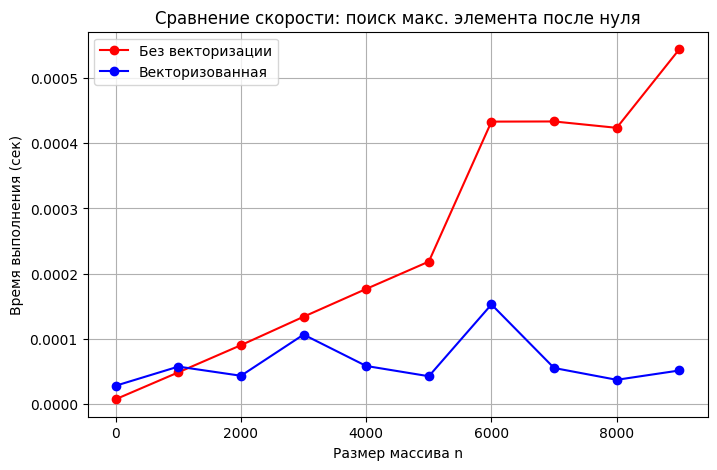

In [142]:
import numpy as np
import time
import matplotlib.pyplot as plt

def use_np(x):
    zero_i = np.where(x == 0)[0]
    next_i = zero_i[zero_i < len(x)-1] + 1
    el_after_zero = x[next_i]
    non_zero = el_after_zero[el_after_zero != 0]
    return np.max(non_zero) if len(non_zero) > 0 else None

def not_use_np(x):
    m = float('-inf')
    for i in range(1, len(x)):
        if x[i-1] == 0 and x[i] > m:  # Исправлено условие
            m = x[i]
    return m if m != float('-inf') else None


sizes = []
for n in range(1, 10000, 1000):
    sizes.append(n)
    
times_use_np = []
times_not_use_np = []

for n in sizes:
    X = np.random.randint(0, 10, size=n)
    
    start = time.time()
    not_use_np(X.tolist())  
    times_not_use_np.append(time.time() - start)
    
    start = time.time()
    use_np(X)
    times_use_np.append(time.time() - start)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times_not_use_np, "r-o", label="Без векторизации")
plt.plot(sizes, times_use_np, "b-o", label="Векторизованная")
plt.xlabel("Размер массива n")
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение скорости: поиск макс. элемента после нуля")
plt.legend()
plt.grid(True)
plt.show()

 
 
* __ Задача 4__: Дан трёхмерный массив, содержащий изображение, размера (height, width, numChannels), а также вектор длины numChannels. Сложить каналы изображения с указанными весами, и вернуть результат в виде матрицы размера (height, width). В ноутбуке приведите пример работы функции – преобразуйте цветное изображение в оттенки серого, использовав коэффициенты np.array([0.299, 0.587, 0.114]). Считать реальное изображение можно при помощи функции scipy.misc.imread (если изображение не в формате png, установите пакет pillow).


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

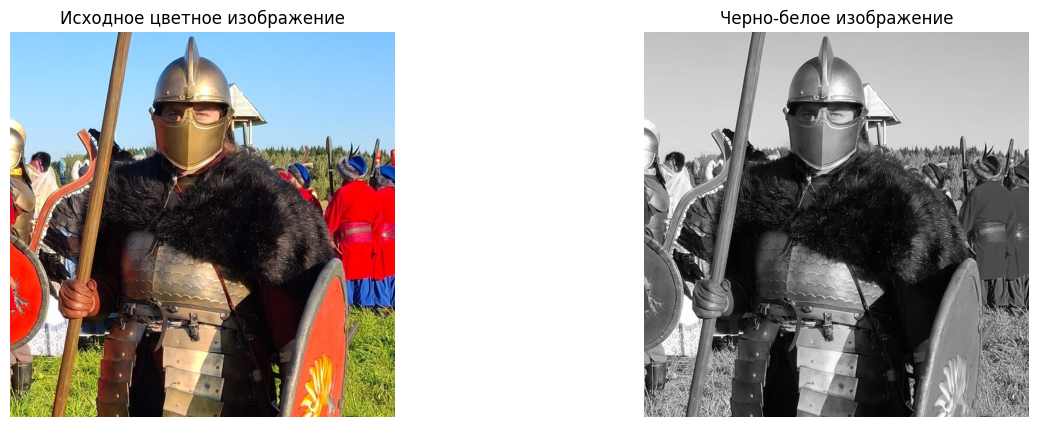

In [128]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

image = iio.imread('warrior.jpg')

if image.dtype == np.uint8:
    image = image.astype(np.float32) / 255.0

filtr = np.array([0.299, 0.587, 0.114])
gray_image = np.sum(image * filtr, axis=2)

# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Исходное цветное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap='gray')
plt.title('Черно-белое изображение')
plt.axis('off')


* __Задача 5__: Реализовать кодирование длин серий (Run-length encoding). Для некоторого вектора x необходимо вернуть кортеж из двух векторов одинаковой длины. Первый содержит числа, а второй - сколько раз их нужно повторить.  
 Например, для x = np.array([2, 2, 2, 3, 3, 3, 5]) ответ – (np.array([2, 3, 5]), np.array([3, 3, 1])).

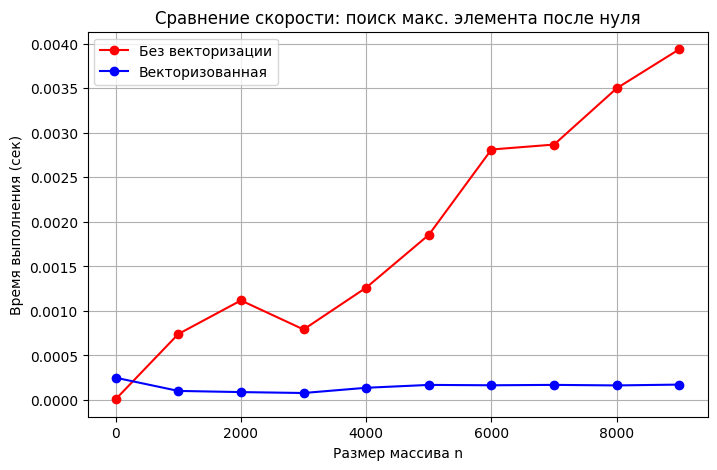

In [144]:
def use_np(x1):
    x1 = np.array([1, 1, 1, 4, 2, 2, 2, 3, 3, 3, 5])
    x = np.append(x1, x1[-1]+1)
    raz = np.diff(x)
    ind_perehod = np.nonzero(raz)
    elem = x1[ind_perehod]
    ind_perehod1 = np.insert(ind_perehod, 0, -1)
    return elem, np.diff(ind_perehod1)

def not_use_np(x1):
    x = x1 + [x1[-1] + 1] if x1 else []
    raz = []
    for i in range(1, len(x)):
        raz.append(x[i] - x[i-1])
    ind_perehod = []
    for i in range(len(raz)):
        if raz[i] != 0:
            ind_perehod.append(i)
    elem = []
    for i in ind_perehod:
        elem.append(x1[i])  
    ind_perehod1 = [-1] + ind_perehod
    diff_ind = []
    for i in range(1, len(ind_perehod1)):
        diff_ind.append(ind_perehod1[i] - ind_perehod1[i-1])
    
    return elem, diff_ind


sizes = []
for n in range(1, 10000, 1000):
    sizes.append(n)
    
times_use_np = []
times_not_use_np = []

for n in sizes:
    X = np.random.randint(0, 10, size=n)
    
    start = time.time()
    not_use_np(X.tolist())  
    times_not_use_np.append(time.time() - start)
    
    start = time.time()
    use_np(X)
    times_use_np.append(time.time() - start)

plt.figure(figsize=(8, 5))
plt.plot(sizes, times_not_use_np, "r-o", label="Без векторизации")
plt.plot(sizes, times_use_np, "b-o", label="Векторизованная")
plt.xlabel("Размер массива n")
plt.ylabel("Время выполнения (сек)")
plt.title("Сравнение скорости: поиск макс. элемента после нуля")
plt.legend()
plt.grid(True)
plt.show()


 
 
* __Задача 6__: Даны две выборки объектов - X и Y. Вычислить матрицу евклидовых расстояний между объектами. Дополнительно сравните с функцией scipy.spatial.distance.cdist по скорости работы (сравнения приведите ниже в ноутбуке).

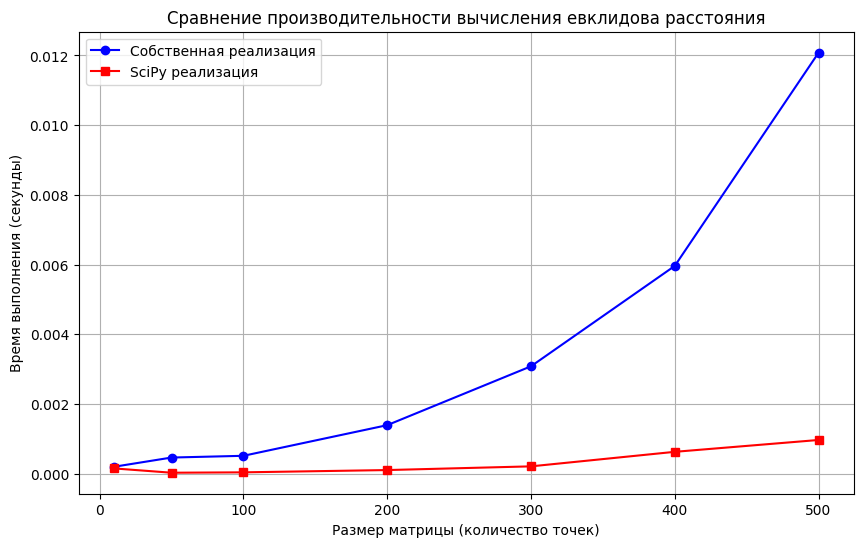

Отношение скоростей для размера 500: 12.45


In [146]:
import numpy as np
from scipy.spatial import distance
import time
import matplotlib.pyplot as plt

def evklid_distance(x1, y1):
    x = x1[:, np.newaxis, :]
    y = y1[np.newaxis, :, :]
    diff = x - y
    squf_diff = diff ** 2
    sum_squf_diff = np.sum(squf_diff, axis=2)
    distances = np.sqrt(sum_squf_diff)
    return distances


sizes = [10, 50, 100, 200, 300, 400, 500]
custom_times = []
scipy_times = []

for size in sizes:
    x1 = np.random.rand(size, 3)
    y1 = np.random.rand(size, 3)
    
    start_time = time.time()
    custom_distances = evklid_distance(x1, y1)
    custom_times.append(time.time() - start_time)
    
    start_time = time.time()
    scipy_distances = distance.cdist(x1, y1, 'euclidean')
    scipy_times.append(time.time() - start_time)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(sizes, custom_times, 'b-', label='Собственная реализация', marker='o')
plt.plot(sizes, scipy_times, 'r-', label='SciPy реализация', marker='s')
plt.xlabel('Размер матрицы (количество точек)')
plt.ylabel('Время выполнения (секунды)')
plt.title('Сравнение производительности вычисления евклидова расстояния')
plt.legend()
plt.grid(True)
plt.savefig('distance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Отношение скоростей для размера {sizes[-1]}: {custom_times[-1]/scipy_times[-1]:.2f}")

### Туториал по Markdown

__(1 балл)__

Напишите краткий (а в данной домашке ещё и почти бесмысленный) отчёт с использованием 4-5 различных вариантов разметки/выделения текста.

# Туториал по Markdown

## Введение
Это *введение* в статью о **Markdown**.

## Основная часть
Преимущества Markdown:
- можно выделять **текст**
- можно зачеркнуть если что-то неправильно написал ~~ой~~
- можно сделать табличку чтобы все поняли
- | КОТ | ПЕС |
|-----|-----|
| МЯУ | ГАВ |



## Заключение
> Markdown - отличный инструмент для быстрого форматирования текста.

Автор: [Святослав Смолин 11в](https://t.me/kanalisvyatika)